# DX 704 Week 2 Project - Time Series Forecasting

<font color = 'red'> FINAL SCORE: 75/80 </font>


This week's project will analyze fresh strawberry price data for a hypothetical "buy low, freeze, and sell high" business.
Strawberries show strong seasonality in their prices compared to other fruits.

![](https://ers.usda.gov/sites/default/files/_laserfiche/Charts/61401/oct14_finding_plattner_fig01.png)

Image source: https://www.ers.usda.gov/amber-waves/2014/october/seasonal-fresh-fruit-price-patterns-differ-across-commodities-the-case-of-strawberries-and-apples

You are considering a business where you buy strawberries when the prices are very low, carefully freeze them, even more carefully defrost them, and then sell them when the prices are high.
You will forecast strawberry price time series and then use them to tactically pick times to buy, freeze, and sell the strawberries.

The full project description, a template notebook, and raw data are available on GitHub at the following link.

https://github.com/bu-cds-dx704/dx704-project-02


### Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Imports

In [1]:
# %pip install prophet

import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np 

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

## Part 1: Backtest Strawberry Prices

Read the provided "strawberry-prices.tsv" with data from 2020 through 2024.
This data is based on data from the U.S. Bureau of Statistics, but transformed so the ground truth is not online.
https://fred.stlouisfed.org/series/APU0000711415

Use the data for 2020 through 2023 to predict monthly prices in 2024.
Spend some time to make sure you are happy with your methodology and prediction accuracy, since you will reuse the methodology to forecast 2025 next.
Save the 2024 backtest predictions as "strawberry-backtest.tsv" with columns 'month' and 'price'.


In [2]:
# YOUR CHANGES HERE


df = pd.read_csv("strawberry-prices.tsv", sep="\t")
print(df.head())

df['month'] = pd.to_datetime(df['month']).dt.normalize()
# print("\n",df.head())
# print(df['month'][2] - df['month'][0])


        month   price
0  2020-01-01  4.0490
1  2020-02-01  3.6250
2  2020-03-01  3.3770
3  2020-04-01  3.2328
4  2020-05-01  3.1260


In [3]:

# Split into training and actual 2024 data
df_train        = df[df['month'].dt.year < 2024]
df_actual_2024  = df[df['month'].dt.year == 2024]

df_prophet = df_train.rename(columns = {'month': 'ds', 'price': 'y'})

# instantiate and fit
model = Prophet(interval_width=0.95, yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
model.fit(df_prophet)


09:58:58 - cmdstanpy - INFO - Chain [1] start processing
09:58:58 - cmdstanpy - INFO - Chain [1] done processing


In [4]:

#  future dataframe for 12 months of 2024
future      = model.make_future_dataframe(periods=12, freq='MS')
forecast    = model.predict(future)
print(forecast.info(), "\n")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          60 non-null     datetime64[ns]
 1   trend                       60 non-null     float64       
 2   yhat_lower                  60 non-null     float64       
 3   yhat_upper                  60 non-null     float64       
 4   trend_lower                 60 non-null     float64       
 5   trend_upper                 60 non-null     float64       
 6   additive_terms              60 non-null     float64       
 7   additive_terms_lower        60 non-null     float64       
 8   additive_terms_upper        60 non-null     float64       
 9   yearly                      60 non-null     float64       
 10  yearly_lower                60 non-null     float64       
 11  yearly_upper                60 non-null     float64       
 

,ds,yhat,yhat_lower,yhat_upper
48,2024-01-01,4.603632,4.285878,4.921554
49,2024-02-01,4.170715,3.866284,4.467426
50,2024-03-01,3.915747,3.623711,4.190535
51,2024-04-01,3.780345,3.463477,4.083929
52,2024-05-01,3.606231,3.289946,3.887371
53,2024-06-01,3.288356,2.991107,3.575894
54,2024-07-01,3.227331,2.928605,3.527425
55,2024-08-01,3.454139,3.136819,3.742546
56,2024-09-01,3.466038,3.184647,3.759938
57,2024-10-01,4.057030,3.780483,4.351763


In [5]:
criteria        = (forecast['ds'].dt.year == 2024)
forecast_2024   = forecast[criteria][['ds', 'yhat']]

# forecast_2024.columns = ['month', 'price']
forecast_2024   = forecast_2024.rename(columns={'ds': 'month', 'yhat': 'price'})
forecast_2024

,month,price
48,2024-01-01,4.603632
49,2024-02-01,4.170715
50,2024-03-01,3.915747
51,2024-04-01,3.780345
52,2024-05-01,3.606231
53,2024-06-01,3.288356
54,2024-07-01,3.227331
55,2024-08-01,3.454139
56,2024-09-01,3.466038
57,2024-10-01,4.057030


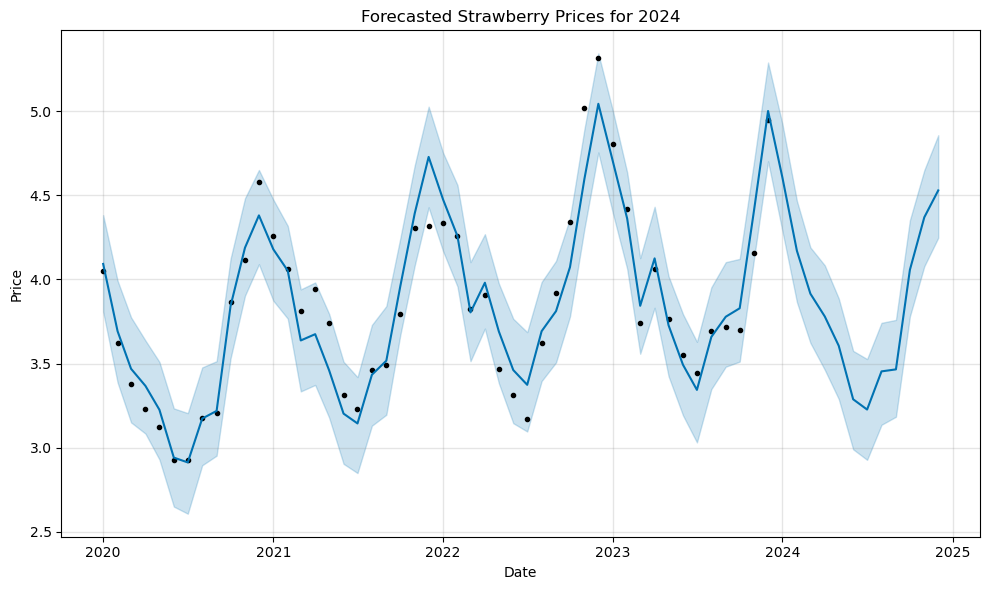

In [6]:

# Plot  forecast
fig1 = model.plot(forecast)
plt.title("Forecasted Strawberry Prices for 2024")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Optional: Plot components (trend, yearly seasonality)
# fig2 = model.plot_components(forecast)
# plt.tight_layout()
# plt.show()


In [7]:

forecast_2024.to_csv("strawberry-backtest.tsv", sep="\t", index=False)


Submit **"strawberry-backtest.tsv"** in Gradescope.

## Part 2: Backtest Errors

What are the mean and standard deviation of the residuals between your backtest predictions and the ground truth? (If your mean is not close to zero, then you may be missing a long term trend.)

Write the mean and standard deviation to a file "backtest-accuracy.tsv" with two columns, mean and std.

In [8]:
# YOUR CHANGES HERE

#  Compare with actual 2024 prices
comparison_df = pd.merge(df_actual_2024, forecast_2024, on='month', suffixes=('_actual', '_predicted'))
comparison_df

,month,price_actual,price_predicted
0,2024-01-01,5.055,4.603632
1,2024-02-01,4.264,4.170715
2,2024-03-01,3.742,3.915747
3,2024-04-01,3.576,3.780345
4,2024-05-01,3.237,3.606231
5,2024-06-01,2.977,3.288356
6,2024-07-01,3.116,3.227331
7,2024-08-01,3.347,3.454139
8,2024-09-01,3.742,3.466038
9,2024-10-01,3.718,4.057030


In [9]:

residuals       = comparison_df['price_actual'] - comparison_df['price_predicted']
mean_residual   = residuals.mean()
std_residual    = residuals.std()

accuracy_df     = pd.DataFrame({'mean': [mean_residual], 'std': [std_residual]})

accuracy_df

,mean,std
0,-0.034773,0.274374


In [10]:
accuracy_df.to_csv("backtest-accuracy.tsv", sep="\t", index=False)

Submit "**backtest-accuracy.tsv**" in Gradescope.

## Part 3: Forecast Strawberry Prices

Use all the data from 2000 through 2024 to predict monthly prices in 2025 using the same methodology from part 1.
Make a monthly forecast for each month of 2025 and save it as "strawberry-forecast.tsv" with columns for month and price.

In [11]:
# YOUR CHANGES HERE

# df

df_prophet_p3   = df.rename(columns={'month': 'ds', 'price': 'y'})
model_p3        = Prophet()
model_p3.fit(df_prophet_p3)

future_2025     = model_p3.make_future_dataframe(periods=12, freq='MS')
forecast_p3     = model_p3.predict(future_2025)


#  forecasted values for 2025
criteria        = forecast_p3['ds'].dt.year == 2025
forecast_2025   = forecast_p3[criteria][['ds', 'yhat']]
forecast_2025   = forecast_2025.rename(columns = {
    'ds': 'month', 
    'yhat': 'price'}
    )

forecast_2025

09:58:58 - cmdstanpy - INFO - Chain [1] start processing


09:58:58 - cmdstanpy - INFO - Chain [1] done processing


,month,price
60,2025-01-01,4.227590
61,2025-02-01,4.139785
62,2025-03-01,3.625474
63,2025-04-01,3.621645
64,2025-05-01,3.334506
65,2025-06-01,3.056036
66,2025-07-01,3.009510
67,2025-08-01,3.263252
68,2025-09-01,3.399879
69,2025-10-01,3.662965


In [12]:

forecast_2025.to_csv("strawberry-forecast.tsv", sep="\t", index=False)

print("Forecast for 2025 saved to 'strawberry-forecast.tsv'.")

Forecast for 2025 saved to 'strawberry-forecast.tsv'.


Submit "**strawberry-forecast.tsv**" in Gradescope.

## Part 4: Buy Low, Freeze and Sell High

Using your 2025 forecast, analyze the profit picking different pairs of months to buy and sell strawberries.
Maximize your profit assuming that it costs &dollar;0.20 per pint to freeze the strawberries, &dollar;0.10 per pint per month to store the frozen strawberries and there is a 10% price discount from selling previously frozen strawberries.
So, if you buy a pint of strawberies for &dollar;1, freeze them, and sell them for &dollar;2 three months after buying them, then the profit is &dollar;2 * 0.9 - &dollar;1 - &dollar;0.20 - &dollar;0.10 * 3 = &dollar;0.30 per pint.
To evaluate a given pair of months, assume that you can invest &dollar;1,000,000 to cover all costs, and that you buy as many pints of strawberries as possible.

Write the results of your analysis to a file "timings.tsv" with columns for the `buy_month`, `sell_month`, `pints_purchased`, and `expected_profit`.

In [13]:
# YOUR CHANGES HERE


forecast_2025_df = pd.read_csv("strawberry-forecast.tsv", sep="\t")

forecast_2025_df['month'] = pd.to_datetime(forecast_2025_df['month'])
forecast_2025_df


,month,price
0,2025-01-01,4.227590
1,2025-02-01,4.139785
2,2025-03-01,3.625474
3,2025-04-01,3.621645
4,2025-05-01,3.334506
5,2025-06-01,3.056036
6,2025-07-01,3.009510
7,2025-08-01,3.263252
8,2025-09-01,3.399879
9,2025-10-01,3.662965


In [14]:
# forecast_2025_df['month'].values[0]

In [15]:

cost_freezing           = 0.20
cost_storage_monthly    = 0.10
discount                = 0.10
investment              = 1E6

results = []


In [16]:
forecast_length = len(forecast_2025_df)
# print(forecast_length)

In [17]:

# Brute force iteration over every possible buy-sell month pairs in 2025
for i in range(forecast_length):
    for j in range(i + 1, forecast_length):  # assume that sell month is after buy month and that there's at least one month of storage cost

        buy_month   = forecast_2025_df.iloc[i] # iloc is for rows by index, remember
        sell_month  = forecast_2025_df.iloc[j]

        buy_price               = buy_month['price']
        gross_sell_price        = sell_month['price']
        # months_stored           = (sell_month['month'] - buy_month['month']).days 
        months_stored           = j - i # number of months between buy and sell month, assumes monthly frequency and avoids stupid date math.
        # print(f'Buy month: {buy_month["month"].strftime('%Y-%m')} | Sell month: {sell_month["month"].strftime('%Y-%m')} | Months stored: {months_stored}')

        # price after discount
        net_sell_price          = gross_sell_price * (1 - discount)
        
        # Total cost per unit
        cost_storage_total  = cost_storage_monthly * months_stored
        total_unit_cost     = buy_price + cost_freezing + cost_storage_total

        # Profit per unit
        profit_per_unit     = net_sell_price - total_unit_cost

            # Number of units that can be purchased
        units_purchased = investment / total_unit_cost
        expected_profit = units_purchased * profit_per_unit

        results.append({
            'buy_month':        buy_month['month'],
            'sell_month':       sell_month['month'],
            'pints_purchased':  int(units_purchased),
            'expected_profit':  expected_profit
        })

results_df = pd.DataFrame(results)
# results_df = results_df.sort_values(by='expected_profit', ascending=False)
results_df.tail(15)

,buy_month,sell_month,pints_purchased,expected_profit
51,2025-07-01,2025-08-01,302159,-112579.671932
52,2025-07-01,2025-09-01,293297,-102542.311148
53,2025-07-01,2025-10-01,284940,-60647.114552
54,2025-07-01,2025-11-01,277045,35939.036671
55,2025-07-01,2025-12-01,269577,97513.861749
56,2025-08-01,2025-09-01,280642,-141264.408233
57,2025-08-01,2025-10-01,272981,-100070.453369
58,2025-08-01,2025-11-01,265727,-6382.587035
59,2025-08-01,2025-12-01,258849,53837.304359
60,2025-09-01,2025-10-01,270279,-108979.376056


In [18]:
results_df.to_csv("timings.tsv", sep = "\t", index = False)

Submit "**timings.tsv**" in Gradescope.

## Part 5: Strategy Check

What is the best profit scenario according to your previous timing analysis?
How much does that profit change if the sell price is off by one standard deviation from your backtest analysis?
(Variation in the sell price is more dangerous because you can see the buy price before fully committing.)

Write the results to a file "check.tsv" with columns `best_profit` and `one_std_profit`.

In [19]:
max_profit  = results_df['expected_profit'].max()
best_row    = results_df.query('expected_profit == @max_profit')

best_row

,buy_month,sell_month,pints_purchased,expected_profit
55,2025-07-01,2025-12-01,269577,97513.861749


In [28]:
adj_forecast_2025_df    = forecast_2025_df.copy()
forecast_2025_stdvn     = adj_forecast_2025_df['price'].std(ddof=1)
print(forecast_2025_stdvn)
adj_forecast_2025_df['adj_price'] = adj_forecast_2025_df['price'] - forecast_2025_stdvn
adj_forecast_2025_df


0.4920891936066876


,month,price,adj_price
0,2025-01-01,4.227590,3.735500
1,2025-02-01,4.139785,3.647696
2,2025-03-01,3.625474,3.133385
3,2025-04-01,3.621645,3.129555
4,2025-05-01,3.334506,2.842417
5,2025-06-01,3.056036,2.563947
6,2025-07-01,3.009510,2.517421
7,2025-08-01,3.263252,2.771163
8,2025-09-01,3.399879,2.907790
9,2025-10-01,3.662965,3.170876


In [21]:
# look up the buy_month and sell_month from best_row in forecast_2025_df. Return the index values of the buy_month and sell_month and the prices 

buy_month   = best_row['buy_month'].values[0]
sell_month  = best_row['sell_month'].values[0]
# print(f'buy_month: {buy_month}, sell_month: {sell_month}')

filtered    = adj_forecast_2025_df.query('month == @buy_month or month == @sell_month')

print(filtered)

        month     price  adj_price
6  2025-07-01  3.009510   2.517421
11 2025-12-01  4.523599   4.031510


In [22]:
buy_price               = filtered['price'].values[0]
gross_sell_price        = filtered['adj_price'].values[1]
net_sell_price          = gross_sell_price * (1 - discount)
months_stored           = filtered.index[1] - filtered.index[0]
# print(f'Buy month: {buy_month["month"].strftime('%Y-%m')} | Sell month: {sell_month["month"].strftime('%Y-%m')} | Months stored: {months_stored}')

print(f'Buy price: ${buy_price:,.2f}')
print(f'Adjusted sell price by one stdvn: ${gross_sell_price:,.2f}')
print(f'Net sell price after {discount*100:.0f}% discount: ${net_sell_price:,.2f}')
print(f'Months stored: {months_stored}')

# Total cost per unit
cost_storage_total  = cost_storage_monthly * months_stored
total_unit_cost     = buy_price + cost_freezing + cost_storage_total
print(f'Total unit cost: ${total_unit_cost:,.2f}')


# Profit per unit
profit_per_unit     = net_sell_price - total_unit_cost
print(f'Profit per unit: ${profit_per_unit:,.2f}')

# if profit_per_unit > 0:
units_purchased     = investment / total_unit_cost     # Number of units that can be purchased
expected_profit     = units_purchased * profit_per_unit
print(f'Units purchased: {int(units_purchased):,}')
print(f'Expected profit: ${expected_profit:,.2f}')

Buy price: $3.01
Adjusted sell price by one stdvn: $4.03
Net sell price after 10% discount: $3.63
Months stored: 5
Total unit cost: $3.71
Profit per unit: $-0.08
Units purchased: 269,577
Expected profit: $-21,876.63


In [23]:
check_df = pd.DataFrame({
    'best_profit': [max_profit],
    'one_std_profit': [expected_profit]
})
check_df


,best_profit,one_std_profit
0,97513.861749,-21876.633578


In [24]:
# Write the results to a file "check.tsv" with columns `best_profit` and `one_std_profit` 

check_df.to_csv("check.tsv", sep="\t", index=False)

Submit "**check.tsv**" in Gradescope.

## Part 6: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "**acknowledgements.txt**" in Gradescope.

## Part 7: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that by manually.

Submit "project.ipynb" in Gradescope.

In [25]:


# # Load the forecast data


# cost_freezing = 0.20
# cost_storage_monthly = 0.10
# discount = 0.10
# investment = 1E6

# # Create a Cartesian product of the DataFrame with itself
# # to get all possible buy_month and sell_month combinations.
# df_pairs = forecast_2025_df.assign(key=1).merge(forecast_2025_df.assign(key=1), on='key', suffixes=('_buy', '_sell'))
# df_pairs = df_pairs.drop('key', axis=1)

# # Filter to keep only valid pairs (sell_month after buy_month)
# df_pairs = df_pairs[df_pairs['month_sell'] > df_pairs['month_buy']].copy()

# # Calculate months stored
# df_pairs['months_stored'] = ((df_pairs['month_sell'] - df_pairs['month_buy']).dt.days // 30).astype(int)

# # Calculate costs and profits
# df_pairs['total_unit_cost'] = df_pairs['price_buy'] + cost_freezing + (df_pairs['months_stored'] * cost_storage_monthly)
# df_pairs['net_sell_price'] = df_pairs['price_sell'] * (1 - discount)
# df_pairs['profit_per_unit'] = df_pairs['net_sell_price'] - df_pairs['total_unit_cost']

# # Calculate total profit
# df_pairs['pints_purchased'] = investment / df_pairs['total_unit_cost']
# df_pairs['expected_profit'] = df_pairs['pints_purchased'] * df_pairs['profit_per_unit']
# df_pairs['pints_purchased'] = df_pairs['pints_purchased'].astype(int)

# # Select and rename columns for the final output
# results_df = df_pairs[['month_buy', 'month_sell', 'pints_purchased', 'expected_profit']].rename(columns={
#     'month_buy': 'buy_month',
#     'month_sell': 'sell_month'
# })

# print(results_df.head())